In [27]:
import pandas as pd
import string
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb

# 1. LISTA DE CARACTERES

In [28]:
# ====================================================================================================================
# Lista de BYTES (0-255) para codificación UTF-8 universal
# Permite encriptar cualquier carácter Unicode: tildes (ó), Cyrillic (Ж), emojis (😀), etc.
# ====================================================================================================================
abc = list(range(256))

# 2. GRADIENTE DE COLORES

In [29]:
# ===================================================================================================================
# Degradado de colores (blanco -> negro) con la misma cantidad de elementos que abc
# ===================================================================================================================
n = len(abc)

# ===================================================================================================================
# Genera tonos de gris en formato hexadecimal: #RRGGBB
# i=0 -> #FFFFFF (blanco) | i=n-1 -> #000000 (negro)
# ===================================================================================================================
gradiente_blanco_negro = [
    f"#{v:02X}{v:02X}{v:02X}"
    for v in [round(255 * (1 - i / (n - 1))) for i in range(n)]
]


## 2.1. Verificación visual del gradiente

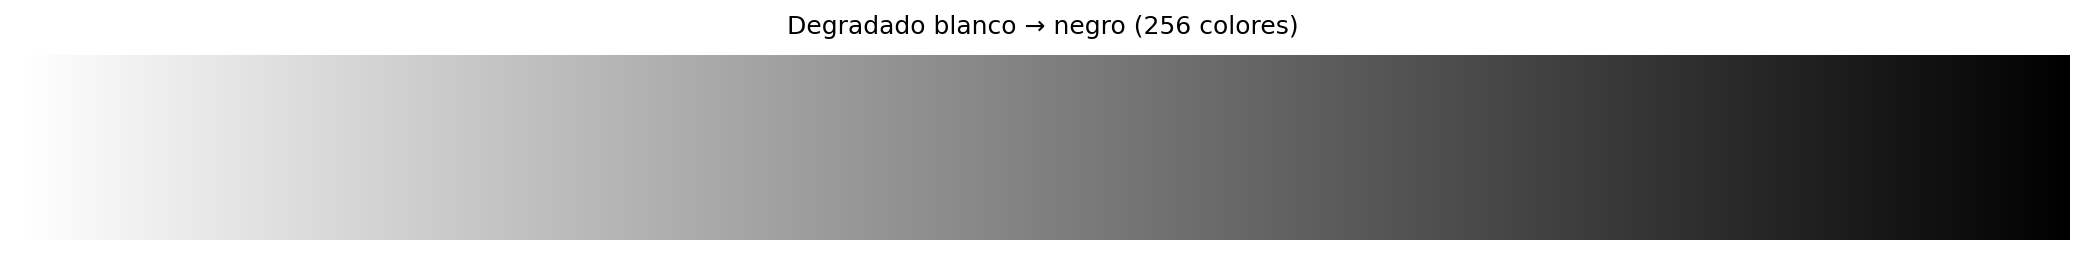

In [30]:
# ===================================================================================================================
# Convierte HEX -> RGB y arma una "imagen" de 1 fila x N columnas
# ===================================================================================================================
rgb = np.array([to_rgb(c) for c in gradiente_blanco_negro])[np.newaxis, :, :]

# ===================================================================================================================
# Mostrar la barra de colores
# ===================================================================================================================
plt.figure(figsize=(14, 1.8), dpi=150)
plt.imshow(rgb, aspect="auto")
plt.axis("off")
plt.title(f"Degradado blanco → negro ({len(gradiente_blanco_negro)} colores)", pad=10)
plt.tight_layout()


# 3. DICCIONARIO DE ASIGNACIÓN

In [31]:
# ===================================================================================================================
# Diccionario que asigna a cada BYTE (0-255) de la lista de bytes un tono del gradiente.
# Con UTF-8, cada byte se codifica a un color único para la visualización.
# ===================================================================================================================
dic = {byte_value: color for byte_value, color in zip(abc, gradiente_blanco_negro)}

# 4. Función para extraer nombre de los campos.

In [32]:
# ===================================================================================================================
# Función para extraer los nombres de las columnas de un DataFrame
# ===================================================================================================================
def ext_columns(df: pd.DataFrame) -> list:
# ===================================================================================================================
# Extraer número de columnas
# ===================================================================================================================
    number_columns = len(df.columns)
# ===================================================================================================================
# Extraer los nombres de las columnas y almacenarlos en una lista como strings.
# ===================================================================================================================
    columns = []
    for i in range(number_columns):
        columns.append(df.columns[i])
    return columns

# 5. Función para extraer los registros por campo

In [33]:
# ===================================================================================================================
# Función para extraer las filas de un DataFrame
# ===================================================================================================================
def ext_rows(df: pd.DataFrame) -> list:
# ===================================================================================================================
# Extraer número de filas
# ===================================================================================================================
    number_rows = len(df)
# ===================================================================================================================
# Extraer las filas y almacenarlas en una lista de listas como strings.
# ===================================================================================================================
    rows = [[] for _ in range(number_rows)]
    for i in range(number_rows):
        for j in (df.columns):
            rows[i].append(str(df[j][i]))
    return rows

# 6. Función para crear lista de caracteres para campos y para registros

In [34]:
def split_cols_rows(df: pd.DataFrame) -> list:
# ===================================================================================================================
# Extraer columnas del DataFrame como listas de bytes (UTF-8)
# ===================================================================================================================
    columns = ext_columns(df)
# ===================================================================================================================
# Crear una lista de BYTES con los nombres de las columnas codificados en UTF-8 con separador '&$&'
# ===================================================================================================================
    campos = []
    for i in range(len(columns)):
        campos += list((columns[i] + '&$&').encode('utf-8'))
# ===================================================================================================================
# Extraer filas del DataFrame como listas de strings
# ===================================================================================================================
    rows = ext_rows(df)
# ===================================================================================================================
# Crear una lista de listas de BYTES con los valores de cada fila codificados en UTF-8 con separador '&$&'
# ===================================================================================================================
    filas = [[] for _ in range(len(rows))]
    for i in range(len(rows)):
        for j in range(len(rows[i])):
            filas[i] += list((rows[i][j] + '&$&').encode('utf-8'))
        filas[i] = filas[i][:-3]

    return campos[:-3], filas

# 7. Función para encriptar en colores los campos y los registros

In [35]:
# ===================================================================================================================
# Función para encriptar un DataFrame convirtiendo cada carácter a su byte UTF-8 y luego a su color correspondiente
# Doble factor de encriptación: n aleatoriza el orden de los bytes, m aleatoriza el orden de los colores.
# ===================================================================================================================
def encript_df(df: pd.DataFrame, n: int, m: int) -> list:

    import random

# ====================================================================================================================
# Lista de BYTES (0-255) para codificación UTF-8 universal
# Permite encriptar cualquier carácter Unicode: tildes (ó), Cyrillic (Ж), emojis (😀), etc.
# Orden aleatorizado según la semilla n.
# ====================================================================================================================
    abc = list(range(256))
    random.seed(n)
    random.shuffle(abc)

# ===================================================================================================================
# Degradado de colores (blanco -> negro) con la misma cantidad de elementos que abc
# ===================================================================================================================
    num = len(abc)

# ===================================================================================================================
# Genera tonos de gris en formato hexadecimal: #RRGGBB
# i=0 -> #FFFFFF (blanco) | i=num-1 -> #000000 (negro)
# Orden aleatorizado según la semilla m.
# ===================================================================================================================
    gradiente_blanco_negro = [
        f"#{v:02X}{v:02X}{v:02X}"
        for v in [round(255 * (1 - i / (num - 1))) for i in range(num)]
    ]
    random.seed(m)
    random.shuffle(gradiente_blanco_negro)

# ===================================================================================================================
# Diccionario que asigna a cada BYTE aleatorizado un tono aleatorizado del gradiente.
# Doble capa de encriptación: byte aleatorio -> color aleatorio.
# ===================================================================================================================
    dic = {byte_value: color for byte_value, color in zip(abc, gradiente_blanco_negro)}
    
# ===================================================================================================================
# Extraer columnas y filas del DataFrame como listas de bytes UTF-8
# ===================================================================================================================
    campos, filas = split_cols_rows(df)
# ===================================================================================================================
# Encriptar cada byte de las columnas y filas utilizando el diccionario de colores
# ===================================================================================================================
    encrypted_campos = [dic[c] for c in campos]
    encrypted_filas = [[dic[c] for c in fila] for fila in filas]
    
    return encrypted_campos, encrypted_filas

# 8. Función para convertir los campos y registros encriptados en una imagen con sus respectivos metadaos.

In [36]:
# ===================================================================================================================
# Función para generar la "imagen" del DataFrame encriptado
# ===================================================================================================================
def plot_df(C, R, show=True):
# ===================================================================================================================
# Generar una lista de filas cuya primera fila corresponde a los encabezados seguida de las filas de datos, todas en
# formato hexadecimal.
# ===================================================================================================================
    filas_hex = [C] + R
# ===================================================================================================================
# Calcular la longitud máxima de las filas para dimensionar la imagen
# ===================================================================================================================
    max_len = max(len(f) for f in filas_hex)
# ===================================================================================================================
# Iniciar una imagen con fondo transparente (RGBA) con el tamaño adecuado para contener todas las filas y columnas
# ===================================================================================================================
    # RGBA: (R,G,B,A)
    img = np.zeros((len(filas_hex), max_len, 4), dtype=float)  # inicia todo transparente (A=0)

    for i, fila in enumerate(filas_hex):
        for j, hx in enumerate(fila):
            r, g, b = to_rgb(hx)
            img[i, j] = [r, g, b, 1.0]  # píxel válido: alpha=1
# ===================================================================================================================
# Mostrar la imagen utilizando Matplotlib (opcional)
# ===================================================================================================================
    if show:
        plt.figure(figsize=(max_len * 0.03, len(filas_hex) * 0.2), dpi=150)
        plt.imshow(img, interpolation="nearest", aspect="auto")
        plt.axis("off")
        plt.tight_layout()
        plt.close()
# ===================================================================================================================
# Generar una lista con las longitudes reales de cada fila para usar como metadata al decodificar.
# ===================================================================================================================
    lengths = [len(f) for f in filas_hex]
    return img, lengths

# 9. Función que guarda imagen y metadatos.

In [37]:
# ===================================================================================================================
# Función para guardar la imagen RGBA y los metadatos de las longitudes de las filas en archivos separados.
# ===================================================================================================================
def guardar_imagen_y_metadata(img, lengths, path_base):

    import json
    from pathlib import Path
    from PIL import Image
# ===================================================================================================================
# Normalizar ruta base y crear carpeta si no existe
# ===================================================================================================================
    p = Path(path_base)
    if p.suffix.lower() == ".png":
        p = p.with_suffix("")
    p.parent.mkdir(parents=True, exist_ok=True)

# ===================================================================================================================
# Guardar imagen RGBA
# ===================================================================================================================
    img_uint8 = np.clip(img * 255, 0, 255).astype(np.uint8)
    img_path = p.with_suffix(".png")
    Image.fromarray(img_uint8, "RGBA").save(img_path)
# ===================================================================================================================
# Guardar metadatos
# ===================================================================================================================
    meta_path = p.parent / f"{p.name}_metadata.json"
    with open(meta_path, "w", encoding="utf-8") as f:
        json.dump({"lengths": lengths}, f, ensure_ascii=False, indent=2)


# 10. Función que lee imagen y metadatos y los decodifica.

In [38]:
# ===================================================================================================================
# Función para cargar un DataFrame desde la imagen RGBA y los metadatos de longitudes, decodificando los colores a bytes
# Doble factor: n aleatoriza los bytes, m aleatoriza los colores (deben coincidir con los usados al encriptar).
# ===================================================================================================================
def cargar_df_desde_imagen(path_base, n: int, m: int, inferir_tipos=True):

    import json, random
    from pathlib import Path
    from PIL import Image
# ===================================================================================================================
# Normalizar ruta base.
# ===================================================================================================================
    p = Path(path_base)
    if p.suffix.lower() == ".png":
        p = p.with_suffix("")

    img_path = p.with_suffix(".png")
    meta_path = p.parent / f"{p.name}_metadata.json"

# ===================================================================================================================
# Cargar metadatos para obtener las longitudes de cada fila (número de píxeles válidos)
# ===================================================================================================================
    with open(meta_path, "r", encoding="utf-8") as f:
        meta = json.load(f)
    lengths = meta["lengths"]

# ===================================================================================================================
# Cargar imagen RGBA y convertirla a un array de NumPy para procesar los píxeles
# ===================================================================================================================
    arr = np.array(Image.open(img_path).convert("RGBA"), dtype=np.uint8)

# ===================================================================================================================
# Reconstruir abc y gradiente aleatorizados con las mismas semillas usadas al encriptar
# ===================================================================================================================
    abc = list(range(256))
    random.seed(n)
    random.shuffle(abc)

    num = len(abc)
    gradiente = [
        f"#{v:02X}{v:02X}{v:02X}"
        for v in [round(255 * (1 - i / (num - 1))) for i in range(num)]
    ]
    random.seed(m)
    random.shuffle(gradiente)
    dic_local = {byte_value: color for byte_value, color in zip(abc, gradiente)}

# ===================================================================================================================
# Mapa RGB -> byte, consistente con el gradiente usado al encriptar
# ===================================================================================================================
    rgb_to_byte = {}
    for b, hx in dic_local.items():
        v = int(hx[1:3], 16)  # gris: R=G=B=v
        rgb_to_byte[(v, v, v)] = b

# ===================================================================================================================
# Decodificar cada fila útil según lengths, convirtiendo los colores RGB a bytes y luego a caracteres UTF-8
# ===================================================================================================================
    textos = []
    for i, row_len in enumerate(lengths):
        fila = arr[i, :row_len, :3]  # tomar solo RGB y solo píxeles válidos
        bytes_row = [rgb_to_byte[(int(px[0]), int(px[1]), int(px[2]))] for px in fila]
        textos.append(bytes(bytes_row).decode("utf-8"))

# ===================================================================================================================
# Reconstruir la primera fila de DataFrame con los nombres de los campos.
# ===================================================================================================================
    columnas = textos[0].split("&$&") if textos else []

# ===================================================================================================================
# Reconstruir las filas restantes del DataFrame.
# ===================================================================================================================
    filas = [t.split("&$&") for t in textos[1:]]

# ===================================================================================================================
# Crear el DataFrame a partir de las filas y columnas decodificadas.
# ===================================================================================================================
    df_rec = pd.DataFrame(filas, columns=columnas)

# ===================================================================================================================
# Inferir tipos numéricos en el DataFrame para aproximar el comportamiento de lectura de CSV.
# ===================================================================================================================
    if inferir_tipos:
        for col in df_rec.columns:
            df_rec[col] = pd.to_numeric(df_rec[col], errors="ignore")

    return df_rec

# 11. Función que codifica y guarda el df codificado.

In [39]:
# ===================================================================================================================
# Función principal para encriptar un DataFrame y guardar la imagen RGBA junto con los metadatos de las longitudes de
# las filas. Doble factor de encriptación: n para los bytes, m para los colores.
# ===================================================================================================================
def Encriptador(df: pd.DataFrame, path: str, n: int, m: int) -> None:
# ===================================================================================================================
# Encriptar el DataFrame mediante la función encript_df.
# ===================================================================================================================
    C, R = encript_df(df, n, m)
# ===================================================================================================================
# Generar la imagen RGBA del DataFrame encriptado y obtener las longitudes de cada fila para metadata.
# ===================================================================================================================
    img, lengths = plot_df(C, R)
# ===================================================================================================================
# Guardar la imagen RGBA y los metadatos de las longitudes de las filas en archivos separados.
# ===================================================================================================================
    guardar_imagen_y_metadata(img, lengths, path)

In [43]:
df = pd.read_csv('Ventas_Company_H.csv')
df.head()

,Anio,Mes,Numero_Total_Ventas,Valor_Total_Ventas
0,2005,1,31870.940650,174918.310181
1,2005,2,37295.094309,206292.028606
2,2005,3,38210.913821,220291.694104
3,2005,4,28489.150407,151573.196578
4,2005,5,37498.452033,131223.848292


In [45]:
path = '/Users/edgaracosta/Documents/CIENCIA_DE_DATOS/GITHUB/Data_Science/CSV_TRANSFORM/VENTAS/'
Encriptador(df, path, n=37, m=101)

In [47]:
df_recuperado = cargar_df_desde_imagen(path, n=37, m=101)

/var/folders/gh/m_mcn3y96_d4tqh_jyd_901w0000gn/T/ipykernel_24388/2036143348.py:85: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_rec[col] = pd.to_numeric(df_rec[col], errors="ignore")


In [48]:
df_recuperado.head()

,Anio,Mes,Numero_Total_Ventas,Valor_Total_Ventas
0,2005,1,31870.940650,174918.310181
1,2005,2,37295.094309,206292.028606
2,2005,3,38210.913821,220291.694104
3,2005,4,28489.150407,151573.196578
4,2005,5,37498.452033,131223.848292
